In [36]:
import scanpy as sc
import muon as mu
import numpy as np
import pandas as pd
from pathlib import Path

SAMPLE_PROCESSED_DATA_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver")


In [ ]:

mdata = mu.read_h5mu(SAMPLE_PROCESSED_DATA_DIR / "multiome_processed.h5mu")
mdata

In [40]:
mdata

MuData object with n_obs × n_vars = 19662 × 168658
  obs:	'leiden', 'hepatocyte_score', 'leiden_mofa_recluster'
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'leiden', 'leiden_colors', 'mofa', 'neighbors', 'umap', 'neighbors_mofa_recluster', 'leiden_mofa_recluster', 'leiden_mofa_recluster_colors'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'neighbors_mofa_recluster_distances', 'neighbors_mofa_recluster_connectivities'
  2 modalities
    rna:	19662 x 19265
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_joint', 'hepatocyte_score', 'leiden_recluster'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'leiden_recluster_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	19662 x 149393
      obs:	'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [2]:
hep_markers = [
    "Alb", "Ttr", "Apoa1", "Apob", "Fgb", "Fga", "Fgg",
    "Ahsg", "Cyp2e1", "Cyp3a11", "Hnf4a", "Asgr1"
]

rna = mdata.mod["rna"]
atac = mdata.mod["atac"]

# Pick markers that are actually present
hep_markers_present = [g for g in hep_markers if g in rna.var_names]

print("Found hepatocyte markers:")
print(hep_markers_present)

sc.tl.score_genes(
    rna,
    gene_list=hep_markers_present,
    score_name="hepatocyte_score",
    use_raw=False
)

# Push score to global mdata.obs so it is easy to subset the full MuData object
mdata.obs["hepatocyte_score"] = rna.obs["hepatocyte_score"]

Found hepatocyte markers:
['Alb', 'Ttr', 'Apoa1', 'Apob', 'Fgb', 'Fga', 'Fgg', 'Ahsg', 'Cyp2e1', 'Cyp3a11', 'Hnf4a', 'Asgr1']


Recluster using MOFA embeddings

In [13]:
sc.pp.neighbors(
    mdata,
    use_rep="X_mofa",
    n_neighbors=20,
    key_added="neighbors_mofa_recluster"
)

sc.tl.leiden(
    mdata,
    resolution=0.1,
    neighbors_key="neighbors_mofa_recluster",
    key_added="leiden_mofa_recluster"
)

sc.tl.umap(
    mdata,
    neighbors_key="neighbors_mofa_recluster"
)

Plot the clusters and hepatocyte scores

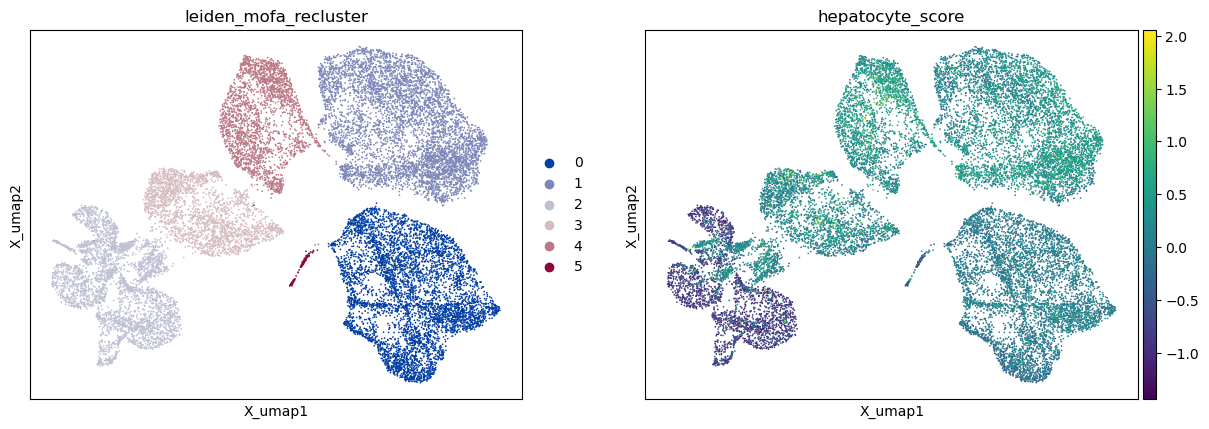

In [14]:
sc.pl.embedding(
    mdata,
    basis="X_umap",
    color=[
        "leiden_mofa_recluster",
        "hepatocyte_score"
    ],
    cmap="viridis"
)

Identify hepatocyte-enriched clusters

In [16]:
cluster_score = (
    mdata.obs
    .groupby("leiden_mofa_recluster")["hepatocyte_score"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print(cluster_score)

                           mean    median  count
leiden_mofa_recluster                           
4                      0.333104  0.310731   2372
1                      0.257794  0.265598   5467
3                      0.149157  0.120473   2410
0                     -0.040056 -0.047688   5498
5                     -0.531704 -0.626733    116
2                     -0.567684 -0.771804   3799


/tmp/ipykernel_3834289/498086345.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_mofa_recluster")["hepatocyte_score"]


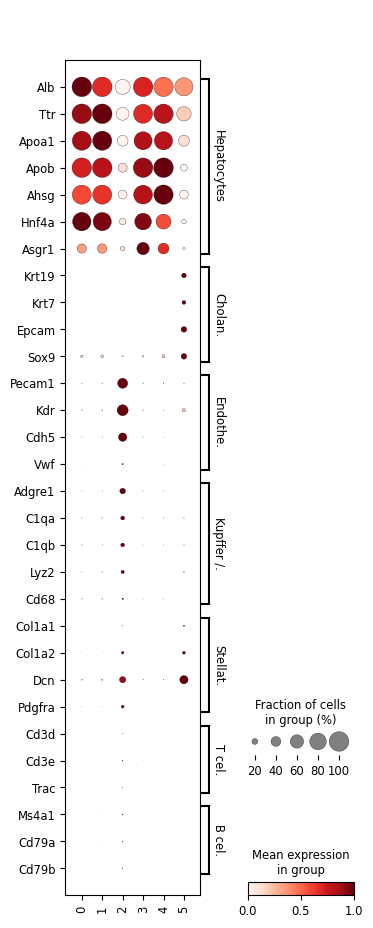

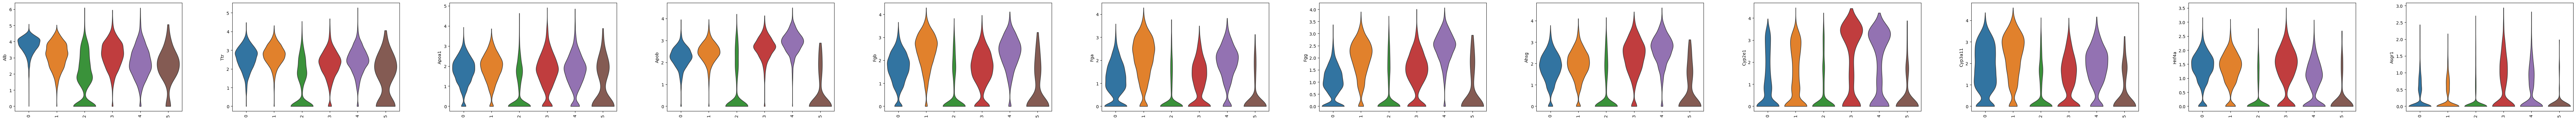

In [22]:
rna.obs["leiden_recluster"] = mdata.obs["leiden_mofa_recluster"]
marker_dict = {
    "Hepatocytes": [
        "Alb", "Ttr", "Apoa1", "Apob", "Ahsg", "Hnf4a", "Asgr1"
    ],
    "Cholangiocytes": [
        "Krt19", "Krt7", "Epcam", "Sox9"
    ],
    "Endothelial": [
        "Pecam1", "Kdr", "Cdh5", "Vwf"
    ],
    "Kupffer / macrophage": [
        "Adgre1", "C1qa", "C1qb", "Lyz2", "Cd68"
    ],
    "Stellate / fibroblast": [
        "Col1a1", "Col1a2", "Dcn", "Pdgfra"
    ],
    "T cells": [
        "Cd3d", "Cd3e", "Trac"
    ],
    "B cells": [
        "Ms4a1", "Cd79a", "Cd79b"
    ]
}

# Keep only genes present in the RNA object
marker_dict_present = {
    group: [g for g in genes if g in rna.var_names]
    for group, genes in marker_dict.items()
}

# Remove empty groups
marker_dict_present = {
    group: genes
    for group, genes in marker_dict_present.items()
    if len(genes) > 0
}

sc.pl.dotplot(
    rna,
    var_names=marker_dict_present,
    groupby="leiden_recluster",
    standard_scale="var",
    dendrogram=False,
    swap_axes=True
)

Markers found:
['Alb', 'Ttr', 'Apoa1', 'Apob', 'Fgb', 'Fga', 'Fgg', 'Ahsg', 'Cyp2e1', 'Cyp3a11', 'Hnf4a', 'Asgr1']


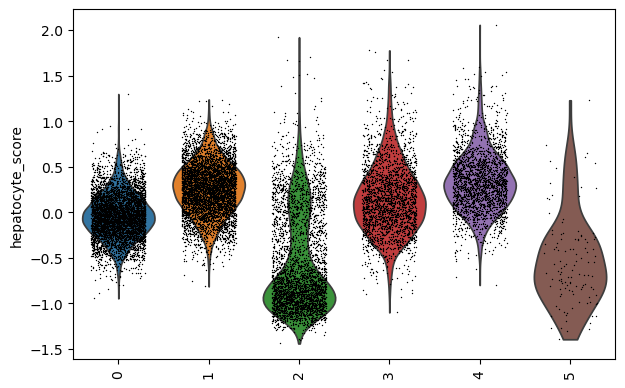

In [41]:
hep_markers = [
    "Alb", "Ttr", "Apoa1", "Apob", "Fgb", "Fga", "Fgg",
    "Ahsg", "Cyp2e1", "Cyp3a11", "Hnf4a", "Asgr1"
]

hep_markers_present = [g for g in hep_markers if g in rna.var_names]

print("Markers found:")
print(hep_markers_present)

sc.tl.score_genes(
    rna,
    gene_list=hep_markers_present,
    score_name="hepatocyte_score",
    use_raw=False
)

# Also store score in global MuData obs
mdata.obs["hepatocyte_score"] = rna.obs["hepatocyte_score"].values

sc.pl.violin(
    rna,
    keys="hepatocyte_score",
    groupby="leiden_recluster",
    rotation=90,
    stripplot=True,
    jitter=0.3
)

Subset hepatocytes from the full MuData object using a threshold

In [42]:
hep_clusters = ["0", "1", "3", "4"]  # Example cluster IDs

hep_mask = (
    mdata.obs["leiden_mofa_recluster"].astype(str).isin(hep_clusters)
)

mdata_hep = mdata[hep_mask, :].copy()
mdata_hep.update()

print(mdata_hep)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 15747 × 168658
  obs:	'leiden', 'hepatocyte_score', 'leiden_mofa_recluster'
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'leiden', 'leiden_colors', 'mofa', 'neighbors', 'umap', 'neighbors_mofa_recluster', 'leiden_mofa_recluster', 'leiden_mofa_recluster_colors'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'neighbors_mofa_recluster_distances', 'neighbors_mofa_recluster_connectivities'
  2 modalities
    rna:	15747 x 19265
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_joint', 'hepatocyte_score', 'leiden_recluster'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersi

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


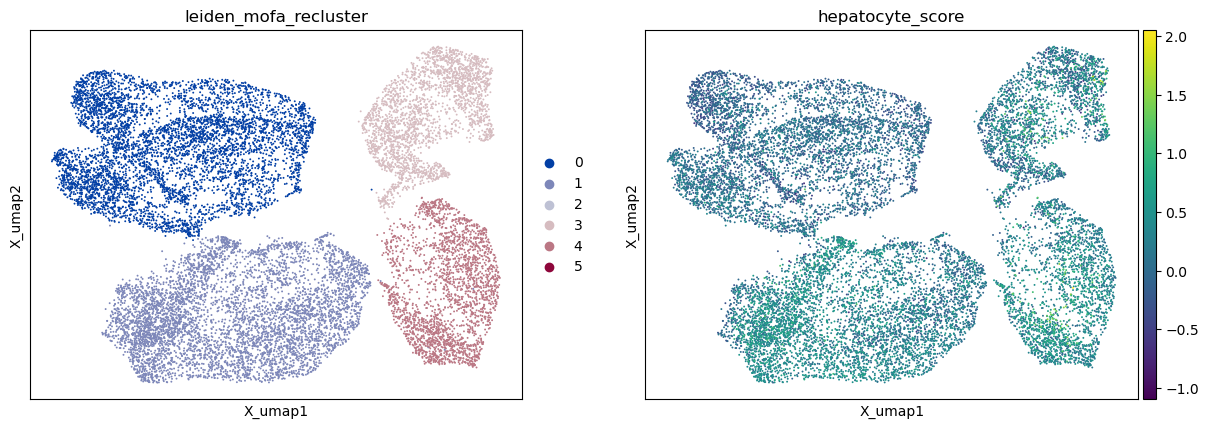

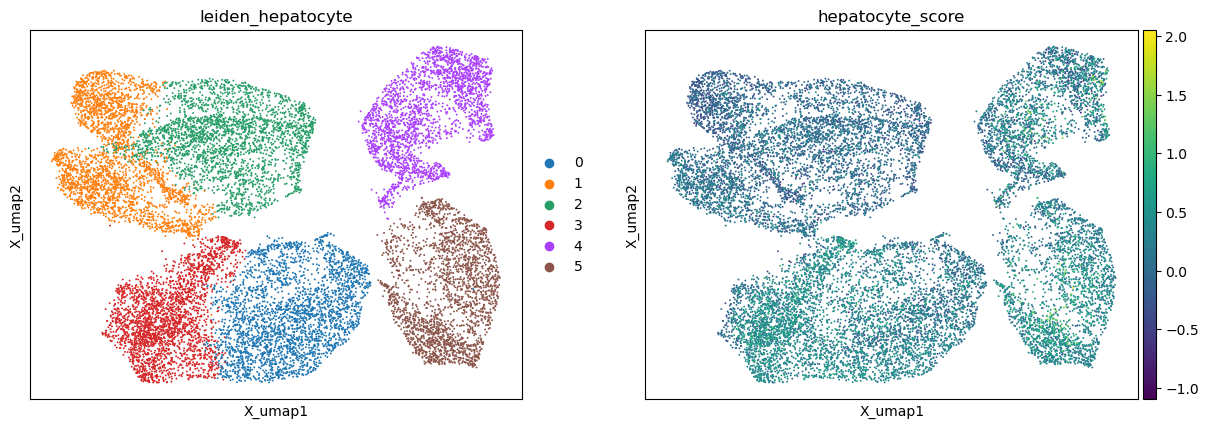

In [45]:
sc.pl.embedding(
    mdata_hep,
    basis="X_umap",
    color=[
        "leiden_mofa_recluster",
        "hepatocyte_score"
    ],
    cmap="viridis"
)

sc.pp.neighbors(
    mdata_hep,
    use_rep="X_mofa",
    n_neighbors=15
)

sc.tl.leiden(
    mdata_hep,
    resolution=0.1,
    key_added="leiden_hepatocyte"
)

sc.tl.umap(mdata_hep)

sc.pl.embedding(
    mdata_hep,
    basis="X_umap",
    color=[
        "leiden_hepatocyte",
        "hepatocyte_score"
    ],
    cmap="viridis"
)

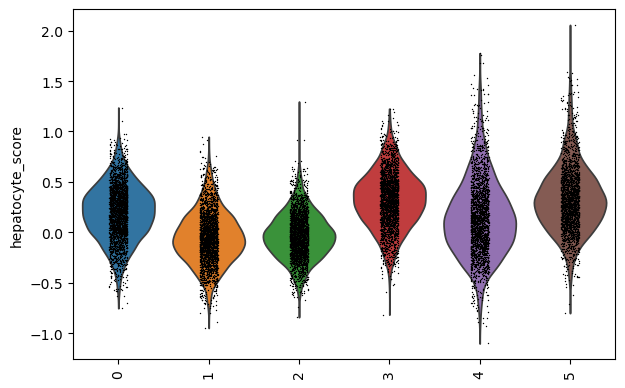

In [46]:
rna_hep = mdata_hep.mod["rna"]

# Make sure score and new cluster labels are available in RNA obs
rna_hep.obs["hepatocyte_score"] = mdata_hep.obs["hepatocyte_score"].values
rna_hep.obs["leiden_hepatocyte"] = mdata_hep.obs["leiden_hepatocyte"].astype(str).values

sc.pl.violin(
    rna_hep,
    keys="hepatocyte_score",
    groupby="leiden_hepatocyte",
    rotation=90,
    stripplot=True
)

In [47]:
mdata_hep.write(SAMPLE_PROCESSED_DATA_DIR / "hepatocytes_filtered.h5mu")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Create metacells

In [48]:
import scipy.sparse as sp

HOPS=2

W = mdata_hep.obsp["connectivities"].tocsr().astype(np.float32)
W = W + sp.diags(np.full(W.shape[0], 1, dtype=np.float32), format="csr")

def row_norm(mat: sp.csr_matrix) -> sp.csr_matrix:
    row_sum = np.asarray(mat.sum(axis=1)).ravel()
    row_sum[row_sum == 0] = 1.0
    inv = sp.diags(1.0 / row_sum, dtype=np.float32)
    return inv @ mat

W = row_norm(W)

W_h = W
for _ in range(1, int(HOPS)):
    W_h = W_h @ W 
    W_h = row_norm(W_h)
W = W_h

# Final row normalization to make sure rows sum to 1
W = row_norm(W)

X_rna = sp.csr_matrix(np.asarray(mdata_hep["rna"].X, dtype=np.float32, order="C"))
X_atac = sp.csr_matrix(np.asarray(mdata_hep["atac"].X, dtype=np.float32, order="C"))

X_rna_soft = W @ X_rna      # cells × genes
X_atac_soft = W @ X_atac 

pseudo_bulk_rna_df = pd.DataFrame(
    X_rna_soft.T.toarray(),
    index=mdata_hep["rna"].var_names,
    columns=mdata_hep["rna"].obs_names,
).fillna(0)

pseudo_bulk_atac_df = pd.DataFrame(
    X_atac_soft.T.toarray(),
    index=mdata_hep["atac"].var_names,
    columns=mdata_hep["atac"].obs_names,
).fillna(0)

pseudobulk_rna_file = SAMPLE_PROCESSED_DATA_DIR / "TG_pseudobulk_hepatocyte.parquet"
pseudobulk_atac_file = SAMPLE_PROCESSED_DATA_DIR / "RE_pseudobulk_hepatocyte.parquet"

print(f"Writing to {pseudobulk_rna_file} and {pseudobulk_atac_file}...")

pseudo_bulk_rna_df.to_parquet(pseudobulk_rna_file, engine="pyarrow", compression="snappy")
pseudo_bulk_atac_df.to_parquet(pseudobulk_atac_file, engine="pyarrow", compression="snappy")


Writing to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/TG_pseudobulk_hepatocyte.parquet and /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/RE_pseudobulk_hepatocyte.parquet...
Found samples: ['6', '4', '1', '3', '7', '5']
Wrote sample 6 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_6/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peaks: 149393
  - Num Metacells: 2327
Wrote sample 4 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_4/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peaks: 149393
  - Num Metacells: 3188
Wrote sample 1 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_1/TG_pseudobulk.parque

In [50]:
# Split the samples into their own files
sample_nums = pseudo_bulk_rna_df.columns.str.split("-").str[1].unique().tolist()
print(f"Found samples: {sample_nums}")
for i in sample_nums:
    rna_mask = pseudo_bulk_rna_df.columns.str.contains(f"-{i}")
    sample_pseudobulk_rna = pseudo_bulk_rna_df.loc[:, rna_mask]
    
    atac_mask = pseudo_bulk_atac_df.columns.str.contains(f"-{i}")
    sample_pseudobulk_atac = pseudo_bulk_atac_df.loc[:, atac_mask]

    sample_pseudobulk_rna_file = SAMPLE_PROCESSED_DATA_DIR / "hepatocytes" / f"hepatocytes_{i}" / "TG_pseudobulk.parquet"
    sample_pseudobulk_atac_file = SAMPLE_PROCESSED_DATA_DIR / "hepatocytes" / f"hepatocytes_{i}" / "RE_pseudobulk.parquet"

    sample_pseudobulk_rna_file.parent.mkdir(parents=True, exist_ok=True)
    sample_pseudobulk_atac_file.parent.mkdir(parents=True, exist_ok=True)

    sample_pseudobulk_rna.to_parquet(sample_pseudobulk_rna_file, engine="pyarrow", compression="snappy")
    sample_pseudobulk_atac.to_parquet(sample_pseudobulk_atac_file, engine="pyarrow", compression="snappy")

    print(f"Wrote sample {i} pseudobulk RNA to {sample_pseudobulk_rna_file}")
    print(f"  - Num Genes: {sample_pseudobulk_rna.shape[0]}")
    print(f"  - Num Peaks: {sample_pseudobulk_atac.shape[0]}")
    print(f"  - Num Metacells: {sample_pseudobulk_rna.shape[1]}")

Found samples: ['6', '4', '1', '3', '7', '5']
Wrote sample 6 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_6/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peaks: 149393
  - Num Metacells: 2327
Wrote sample 4 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_4/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peaks: 149393
  - Num Metacells: 3188
Wrote sample 1 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_1/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peaks: 149393
  - Num Metacells: 3151
Wrote sample 3 pseudobulk RNA to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/hepatocytes/hepatocytes_3/TG_pseudobulk.parquet
  - Num Genes: 19265
  - Num Peak